# WQD7013 Final Project

**Dataset A (corrected): Diabetes 130-US Hospitals for Years 1999–2008** (UCI ML Repository; Strack et al. 2014, CC BY 4.0)

**Primary question.** *What patient characteristics, clinical complexity indicators, and diabetes management factors best predict early hospital readmission (within 30 days), and does the effect of HbA1c measurement on readmission risk differ across admission types?*

# 1. Dataset Audit & Exploratory Analysis


**Classification decisions used throughout (justified in §1.1b):**
- `age` (10-year bins) → **midpoint-numeric** (continuous).
- `A1Cresult`, `max_glu_serum` → **ordinal** with an explicit `Not measured` level ("test not ordered" is a clinical state, not missing).
- `time_in_hospital` → **discrete count, analysed as continuous** (CLT justified by large n).
- `admission_type_id`, `discharge_disposition_id`, `admission_source_id` → **nominal**, decoded via `IDS_mapping.csv`.

In [2]:
import warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
warnings.filterwarnings("ignore")
np.random.seed(42)
pd.set_option("display.max_columns", 60)

# --- read dataset directly from GitHub ---
GITHUB_RAW = "https://raw.githubusercontent.com/unluckytau/WQD7013-Final-Project/refs/heads/main/dataset"
DATA = f"{GITHUB_RAW}/diabetic_data.csv"
MAP  = f"{GITHUB_RAW}/IDS_mapping.csv"
print("Loading:", DATA)

Loading: https://raw.githubusercontent.com/unluckytau/WQD7013-Final-Project/refs/heads/main/dataset/diabetic_data.csv


## 1.1 Structural Audit & Variable Classification

In [3]:
# Load — missing values are the literal '?' (NOT blank cells)
df = pd.read_csv(DATA, na_values="?", low_memory=False)
print(f"Shape: {df.shape[0]:,} encounters x {df.shape[1]} variables")
print(f"Unique patients: {df['patient_nbr'].nunique():,}  |  max encounters per patient: {df['patient_nbr'].value_counts().max()}")
df.head(3)

Shape: 101,766 encounters x 50 variables
Unique patients: 71,518  |  max encounters per patient: 40


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO


In [4]:
import urllib.request

def load_map(path):
    if str(path).startswith("http"):
        text = urllib.request.urlopen(path).read().decode("utf-8")
    else:
        with open(path) as f:
            text = f.read()

    maps, cur = {}, None
    for line in text.splitlines():
        if line.endswith(",description"):
            cur = line.split(",")[0]
            maps[cur] = {}
        elif cur and "," in line and line.strip(","):
            k = line.split(",")[0].strip()
            v = line.split(",", 1)[1].strip().strip('"')
            if k.isdigit():
                maps[cur][int(k)] = v
    return maps

maps = load_map(MAP)
for col in ["admission_type_id", "discharge_disposition_id", "admission_source_id"]:
    df[col + "_label"] = df[col].map(maps[col]).fillna("Unknown")

### 1.1(a) Variable inventory table
Each variable classified by inferred dtype, corrected type, measurement level, and role in the primary (readmission) question.

In [5]:
inventory = [
 ("encounter_id","int64","int","discrete","Identifier (drop)"),
 ("patient_nbr","int64","int","discrete","Identifier / clustering key"),
 ("race","object","category","nominal","Confounder"),
 ("gender","object","category","nominal","Predictor"),
 ("age","object","ordinal bins -> midpoint","ordinal/continuous","Predictor"),
 ("weight","object","mostly missing","continuous(bins)","Irrelevant (~97% missing)"),
 ("admission_type_id","int64","category (coded)","nominal","Predictor / moderator"),
 ("discharge_disposition_id","int64","category (coded)","nominal","Predictor (filter death/hospice)"),
 ("admission_source_id","int64","category (coded)","nominal","Predictor"),
 ("time_in_hospital","int64","int","discrete->continuous","OUTCOME (Part 3)"),
 ("payer_code","object","category","nominal","Irrelevant/admin (~40% missing)"),
 ("medical_specialty","object","category","nominal","Confounder (~49% missing)"),
 ("num_lab_procedures","int64","int","discrete","Predictor (complexity)"),
 ("num_procedures","int64","int","discrete","Predictor (complexity)"),
 ("num_medications","int64","int","discrete","Predictor (complexity)"),
 ("number_outpatient","int64","int","discrete","Predictor (prior utilisation)"),
 ("number_emergency","int64","int","discrete","Predictor (prior utilisation)"),
 ("number_inpatient","int64","int","discrete","Predictor (strong)"),
 ("diag_1","object","ICD-9 -> 9 groups","nominal","Predictor (primary dx)"),
 ("diag_2","object","ICD-9 -> 9 groups","nominal","Predictor"),
 ("diag_3","object","ICD-9 -> 9 groups","nominal","Predictor"),
 ("number_diagnoses","int64","int","discrete","Predictor (severity)"),
 ("max_glu_serum","object","ordinal + Not measured","ordinal","Predictor"),
 ("A1Cresult","object","ordinal + Not measured","ordinal","KEY predictor (HbA1c)"),
 ("metformin ... metformin-pioglitazone (24 drug cols)","object","ordinal (No/Steady/Up/Down)","ordinal","Predictors (Lasso, Part 5)"),
 ("change","object","binary","nominal","Predictor"),
 ("diabetesMed","object","binary","nominal","Predictor"),
 ("readmitted","object","3-level -> binary <30","ordinal/nominal","Source of binary OUTCOME (Part 4)"),
]
inv = pd.DataFrame(inventory, columns=["variable","inferred_dtype","corrected_type","measurement_level","role"])
inv

,variable,inferred_dtype,corrected_type,measurement_level,role
0,encounter_id,int64,int,discrete,Identifier (drop)
1,patient_nbr,int64,int,discrete,Identifier / clustering key
2,race,object,category,nominal,Confounder
3,gender,object,category,nominal,Predictor
4,age,object,ordinal bins -> midpoint,ordinal/continuous,Predictor
5,weight,object,mostly missing,continuous(bins),Irrelevant (~97% missing)
6,admission_type_id,int64,category (coded),nominal,Predictor / moderator
7,discharge_disposition_id,int64,category (coded),nominal,Predictor (filter death/hospice)
8,admission_source_id,int64,category (coded),nominal,Predictor
9,time_in_hospital,int64,int,discrete->continuous,OUTCOME (Part 3)


### 1.1(b) Ambiguous classifications — defence

**`age` (stored as 10-year bins).** Inferred dtype is `object`; the correct measurement level is ambiguous between *ordinal* and *continuous*. We treat it as **continuous via bin midpoints** ([70-80)→75). Justification: the bins are equal-width and monotone, so the midpoint is an unbiased representative of each interval under a uniform-within-bin assumption; this lets age enter regression as a **single interpretable slope** (years), preserves statistical power, and avoids spending 9 degrees of freedom on dummies. *Consequence of misclassification:* treating the raw bin index as a plain number is the same midpoint logic but mislabels the unit; treating age as unordered **nominal** would discard the ordering and inflate model complexity, while forcing it ordinal with rank scores (1–10) imposes equal spacing on an arbitrary scale and makes the coefficient uninterpretable in years.

**`A1Cresult` / `max_glu_serum`.** Ambiguity is two-fold: (i) ordinal vs nominal, and (ii) whether the dominant level is "missing". We treat them as **ordinal** (`Norm` < `>7` < `>8`; `Norm` < `>200` < `>300`) with an explicit **`Not measured`** level. Justification: the levels are clinically ordered severities, and the question targets the *effect of HbA1c measurement* — so whether the test was ordered is itself informative and must be retained, not deleted. *Consequence of misclassification:* counting `Not measured` (83% of `A1Cresult`) as missing would trigger near-total listwise deletion or nonsensical imputation and destroy the central HbA1c signal; ignoring the ordering would forgo the dose–response interpretation the primary question depends on.

### 1.1(c) Missing-data audit + mechanism classification

,n_missing,pct_missing
weight,98569,96.86
max_glu_serum,96420,94.75
A1Cresult,84748,83.28
medical_specialty,49949,49.08
payer_code,40256,39.56
race,2273,2.23
diag_3,1423,1.40
diag_2,358,0.35
diag_1,21,0.02


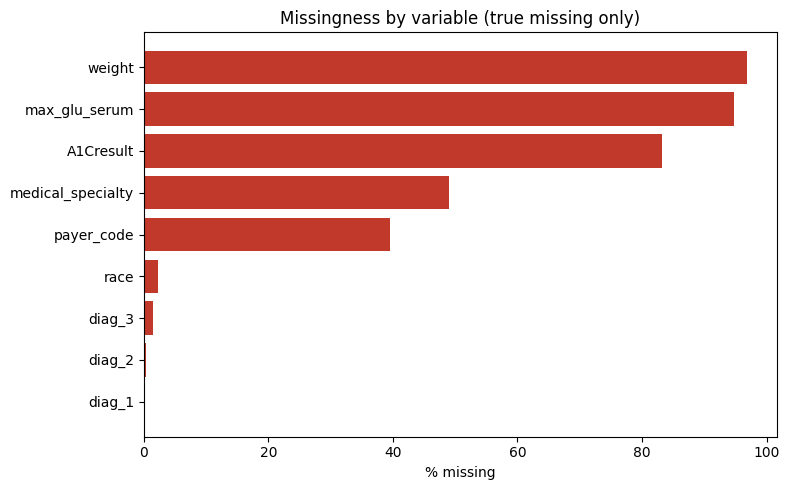

In [6]:
miss = pd.DataFrame({"n_missing": df.isna().sum(),
                     "pct_missing": (df.isna().mean()*100).round(2)})
miss = miss[miss.n_missing > 0].sort_values("pct_missing", ascending=False)
display(miss)

plt.figure(figsize=(8,5))
plt.barh(miss.index[::-1], miss.pct_missing[::-1], color="#c0392b")
plt.xlabel("% missing"); plt.title("Missingness by variable (true missing only)")
plt.tight_layout(); plt.show()

In [7]:
# MAR test: does medical_specialty missingness depend on admission type?
df["medspec_missing"] = df["medical_specialty"].isna().astype(int)
ct = pd.crosstab(df["admission_type_id_label"], df["medspec_missing"])
chi2, p_ms, dof, _ = stats.chi2_contingency(ct)
print(f"medical_specialty missingness vs admission type: chi2={chi2:.1f}, dof={dof}, p={p_ms:.2e}")

# MNAR evidence: weight-missing patients differ in severity (number_diagnoses)?
df["weight_missing"] = df["weight"].isna().astype(int)
g1 = df.loc[df.weight_missing==1, "number_diagnoses"]; g0 = df.loc[df.weight_missing==0, "number_diagnoses"]
t_w, p_w = stats.ttest_ind(g1, g0, equal_var=False)
print(f"number_diagnoses: weight-missing mean={g1.mean():.2f} vs recorded mean={g0.mean():.2f}, Welch p={p_w:.2e}")

medical_specialty missingness vs admission type: chi2=9228.1, dof=7, p=0.00e+00
number_diagnoses: weight-missing mean=7.40 vs recorded mean=7.98, Welch p=2.29e-89


**Mechanism classification (variables >5% missing):**

- **`weight` (96.9%) → MNAR.** Recording is tied to clinical workflow/severity; weight-missing encounters have significantly *fewer* diagnoses (7.40 vs 7.98, p≈10⁻⁸⁹), so missingness depends on patient state. Effectively unusable — drop.
- **`medical_specialty` (49.1%) → MAR.** Missingness is strongly associated with admission type (χ²≈9228, df=7, p<0.001), i.e. it depends on an *observed* variable. Can be modelled with a `Missing` indicator category.
- **`payer_code` (39.6%) → MAR/MCAR-leaning, administrative.** Reflects billing/data-entry, not clinical state; not a predictor of interest. Retain as `Unknown` category or drop.
- `race` (2.2%), `diag_3` (1.4%), `diag_2`/`diag_1` (<0.5%) are below the 5% threshold; handle with an explicit `Unknown`/`Other` category.

### 1.1(d) [JUSTIFY] Handling the two highest-missing variables

In [8]:
# weight parsed to numeric midpoints to compare imputation strategies numerically
def wmid(x):
    if pd.isna(x): return np.nan
    x = x.strip("[]()").replace(">","").replace("<","")
    if "-" in x:
        a,b = x.split("-"); return (float(a)+float(b))/2
    try: return float(x)
    except: return np.nan
df["weight_mid"] = df["weight"].apply(wmid)
w = df["weight_mid"]
comp = pd.DataFrame({
 "strategy":["Listwise (observed only)","Mean imputation","Median imputation"],
 "n_used":[int(w.notna().sum()), len(w), len(w)],
 "mean":[w.dropna().mean(), w.fillna(w.mean()).mean(), w.fillna(w.median()).mean()],
 "std":[w.dropna().std(), w.fillna(w.mean()).std(), w.fillna(w.median()).std()],
}).round(2)
display(comp)
print("medical_specialty: 49% missing -> compare drop vs 'Missing' indicator category")
print(df["medical_specialty"].fillna("Missing").value_counts().head(6))

,strategy,n_used,mean,std
0,Listwise (observed only),3197,86.27,26.03
1,Mean imputation,101766,86.27,4.61
2,Median imputation,101766,87.46,4.62


medical_specialty: 49% missing -> compare drop vs 'Missing' indicator category
medical_specialty
Missing                   49949
InternalMedicine          14635
Emergency/Trauma           7565
Family/GeneralPractice     7440
Cardiology                 5352
Surgery-General            3099
Name: count, dtype: int64


**[JUSTIFY] Decision.** The two highest-missing variables are `weight` (96.9%) and `medical_specialty` (49.1%).

*`weight`:* Only 3,197 of 101,766 values are observed. **Listwise deletion** would discard 97% of the data — catastrophic. **Mean/median imputation** is worse than useless here: filling 96.9% of rows with one constant collapses the standard deviation from **26.03** (observed) to **≈4.6**, manufacturing false precision and destroying any real variance — and because the mechanism is **MNAR**, the imputed values are systematically biased. **Multiple imputation** is not defensible either: with 97% missing there is essentially no observed information to build a donor model on, and MNAR violates MI's MAR assumption. **Final choice: drop `weight` entirely** and document it as an MNAR limitation.

*`medical_specialty`:* At 49% missing and **MAR**, deletion would halve the sample and bias it toward admission types that record specialty. The principled choice is to **retain it with an explicit `Missing` category** (a "missing-indicator" approach), which preserves all rows and lets the model learn whether *having an unrecorded specialty* is itself predictive — appropriate because missingness here depends on observed admission type.

## 1.2 Univariate Distributions

In [9]:
CONT = ["time_in_hospital","num_lab_procedures","num_procedures","num_medications",
        "number_outpatient","number_emergency","number_inpatient","number_diagnoses"]
def describe(s):
    s = s.dropna()
    return pd.Series({"mean":s.mean(),"median":s.median(),"sd":s.std(),
        "IQR":s.quantile(.75)-s.quantile(.25),"skew":s.skew(),
        "exc_kurtosis":s.kurtosis(),"p5":s.quantile(.05),"p95":s.quantile(.95)})
uni = df[CONT].apply(describe).T.round(2)
uni

,mean,median,sd,IQR,skew,exc_kurtosis,p5,p95
time_in_hospital,4.40,4.0,2.99,4.0,1.13,0.85,1.0,11.0
num_lab_procedures,43.10,44.0,19.67,26.0,-0.24,-0.25,4.0,73.0
num_procedures,1.34,1.0,1.71,2.0,1.32,0.86,0.0,5.0
num_medications,16.02,15.0,8.13,10.0,1.33,3.47,6.0,31.0
number_outpatient,0.37,0.0,1.27,0.0,8.83,147.91,0.0,2.0
number_emergency,0.20,0.0,0.93,0.0,22.86,1191.69,0.0,1.0
number_inpatient,0.64,0.0,1.26,1.0,3.61,20.72,0.0,3.0
number_diagnoses,7.42,8.0,1.93,3.0,-0.88,-0.08,4.0,9.0


### 1.2(b) Histograms + Freedman–Diaconis bin count

time_in_hospital: n=101,766, IQR=4.0, bin width h=2*IQR/n^(1/3)=0.171 -> 76 bins
num_medications: n=101,766, IQR=10.0, bin width h=2*IQR/n^(1/3)=0.428 -> 187 bins
num_lab_procedures: n=101,766, IQR=26.0, bin width h=2*IQR/n^(1/3)=1.114 -> 118 bins


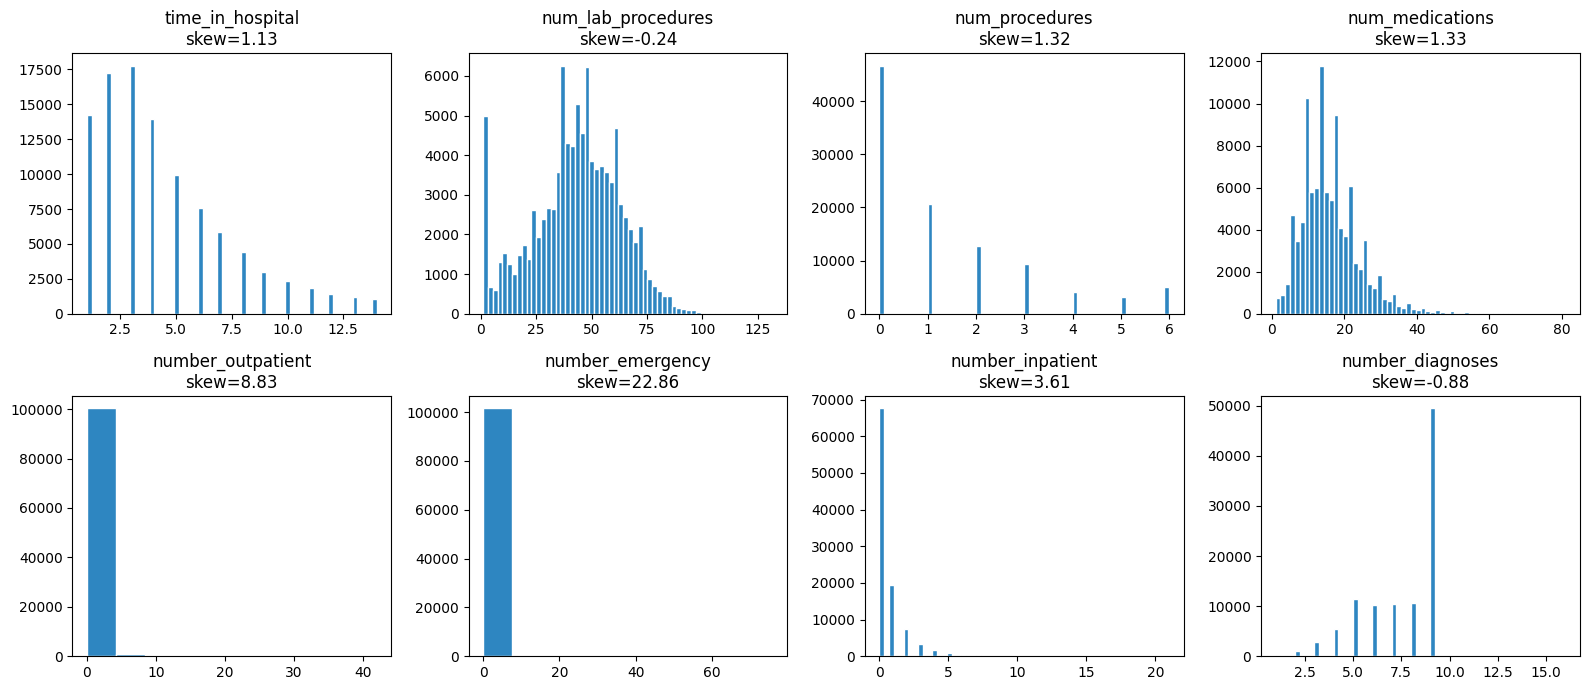

In [10]:
def fd_bins(s):
    s = s.dropna(); n = len(s); iqr = s.quantile(.75)-s.quantile(.25)
    h = 2*iqr/(n**(1/3)); k = int(np.ceil((s.max()-s.min())/h)) if h>0 else 10
    return n, iqr, h, k
for c in ["time_in_hospital","num_medications","num_lab_procedures"]:
    n,iqr,h,k = fd_bins(df[c])
    print(f"{c}: n={n:,}, IQR={iqr:.1f}, bin width h=2*IQR/n^(1/3)={h:.3f} -> {k} bins")

fig,axes = plt.subplots(2,4,figsize=(16,7))
for ax,c in zip(axes.ravel(), CONT):
    s = df[c].dropna(); _,_,_,k = fd_bins(s)
    ax.hist(s, bins=min(k,60), color="#2e86c1", edgecolor="white")
    ax.set_title(f"{c}\nskew={s.skew():.2f}")
plt.tight_layout(); plt.show()

### 1.2(c) [JUSTIFY] Outcome distribution & transformation

Shapiro-Wilk (n=5000 subsample): W=0.8857, p=1.76e-51
Kolmogorov-Smirnov: D=0.1729, p=0.00e+00
skewness raw  : 1.134
skewness sqrt : 0.474
skewness log  : -0.204


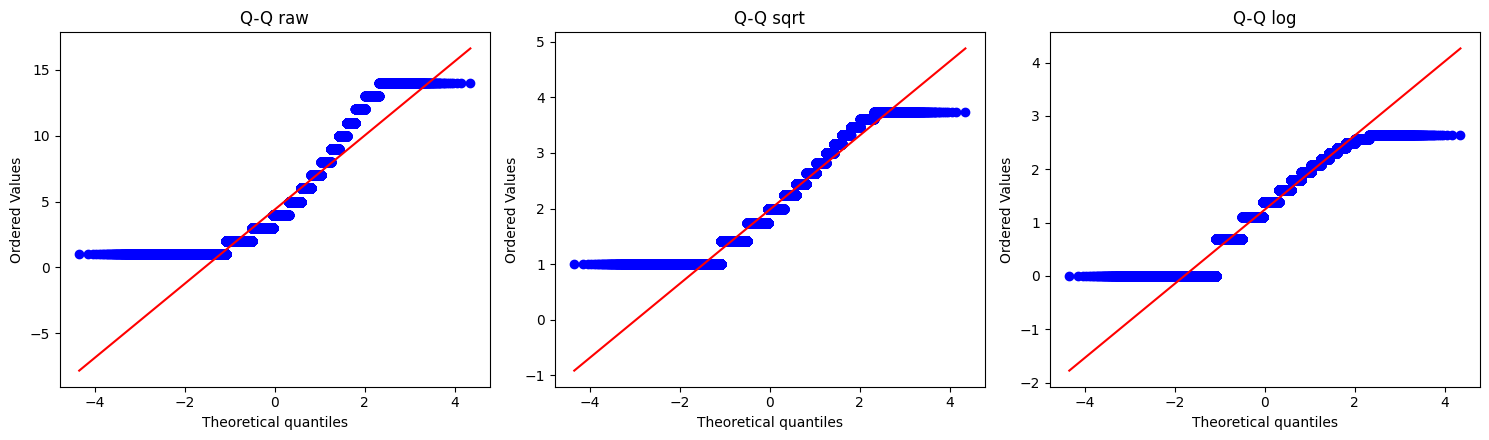

In [11]:
y = df["time_in_hospital"].astype(float)
W,pW = stats.shapiro(y.sample(5000, random_state=1))
D,pD = stats.kstest((y-y.mean())/y.std(), "norm")
print(f"Shapiro-Wilk (n=5000 subsample): W={W:.4f}, p={pW:.2e}")
print(f"Kolmogorov-Smirnov: D={D:.4f}, p={pD:.2e}")
for label, t in [("raw",y),("sqrt",np.sqrt(y)),("log",np.log(y))]:
    print(f"skewness {label:5s}: {pd.Series(t).skew():.3f}")

fig,ax = plt.subplots(1,3,figsize=(15,4.5))
for a,(lab,t) in zip(ax,[("raw",y),("sqrt",np.sqrt(y)),("log",np.log(y))]):
    stats.probplot(t,dist="norm",plot=a); a.set_title(f"Q-Q {lab}")
plt.tight_layout(); plt.show()

### 1.2(d) Categorical frequencies & rare categories (<30)

In [12]:
CAT = ["race","gender","age","A1Cresult","max_glu_serum","change","diabetesMed",
       "admission_type_id_label","readmitted"]
for c in CAT:
    vc = df[c].value_counts(dropna=False)
    prop = (vc/len(df)*100).round(2)
    print(f"\n=== {c} ===")
    print(pd.DataFrame({"count":vc,"pct":prop}).to_string())
print("\nRare categories (<30 obs):")
for c in CAT:
    vc = df[c].value_counts(dropna=False); rr = vc[vc<30]
    if len(rr): print(" ", c, dict(rr))


=== race ===
                 count    pct
race                         
Caucasian        76099  74.78
AfricanAmerican  19210  18.88
NaN               2273   2.23
Hispanic          2037   2.00
Other             1506   1.48
Asian              641   0.63

=== gender ===
                 count    pct
gender                       
Female           54708  53.76
Male             47055  46.24
Unknown/Invalid      3   0.00

=== age ===
          count    pct
age                   
[70-80)   26068  25.62
[60-70)   22483  22.09
[50-60)   17256  16.96
[80-90)   17197  16.90
[40-50)    9685   9.52
[30-40)    3775   3.71
[90-100)   2793   2.74
[20-30)    1657   1.63
[10-20)     691   0.68
[0-10)      161   0.16

=== A1Cresult ===
           count    pct
A1Cresult              
NaN        84748  83.28
>8          8216   8.07
Norm        4990   4.90
>7          3812   3.75

=== max_glu_serum ===
               count    pct
max_glu_serum              
NaN            96420  94.75
Norm            2597 

**Rare-category handling.** Only two variables have categories below 30 observations: `gender` = *Unknown/Invalid* (n=3) and `admission_type_id` = *Trauma Center* (n=21) and *Newborn* (n=10). Decision: **drop** the 3 `Unknown/Invalid` gender rows (data error, negligible loss); **collapse** the tiny admission-type levels into an `Other` group when building the grouped admission-type predictor, so no model estimates a coefficient from <30 cases (which would be high-variance and unstable).

## 1.3 Bivariate Relationships

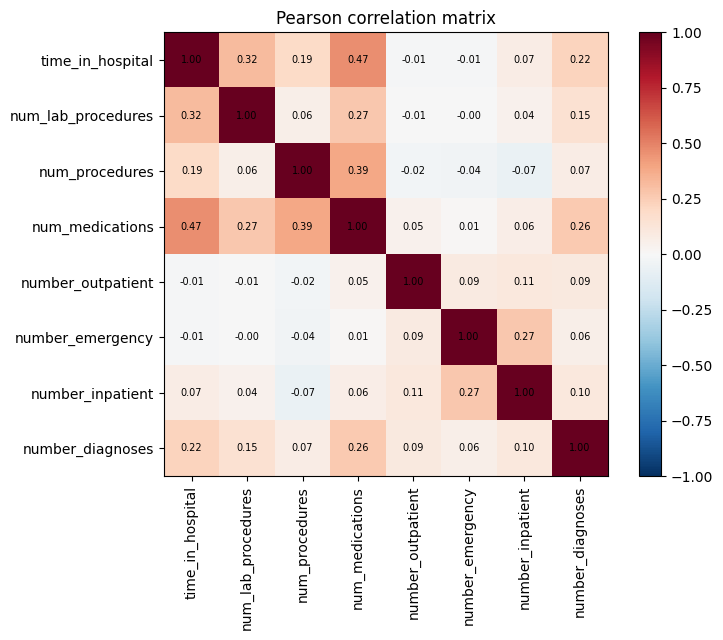

Top-3 |r| pairs (Pearson vs Spearman):
  time_in_hospital ~ num_medications: Pearson=0.466, Spearman=0.465
  num_procedures ~ num_medications: Pearson=0.386, Spearman=0.352
  time_in_hospital ~ num_lab_procedures: Pearson=0.318, Spearman=0.337


In [13]:
corr = df[CONT].corr(method="pearson")
plt.figure(figsize=(8,6.5))
im = plt.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1); plt.colorbar(im, fraction=0.046)
plt.xticks(range(len(CONT)), CONT, rotation=90); plt.yticks(range(len(CONT)), CONT)
for i in range(len(CONT)):
    for j in range(len(CONT)):
        plt.text(j,i,f"{corr.iloc[i,j]:.2f}",ha="center",va="center",fontsize=7)
plt.title("Pearson correlation matrix"); plt.tight_layout(); plt.show()

pairs=[]
for i in range(len(CONT)):
    for j in range(i+1,len(CONT)): pairs.append((CONT[i],CONT[j],corr.iloc[i,j]))
pairs.sort(key=lambda t:abs(t[2]),reverse=True)
print("Top-3 |r| pairs (Pearson vs Spearman):")
for a,b,r in pairs[:3]:
    print(f"  {a} ~ {b}: Pearson={r:.3f}, Spearman={stats.spearmanr(df[a],df[b]).statistic:.3f}")

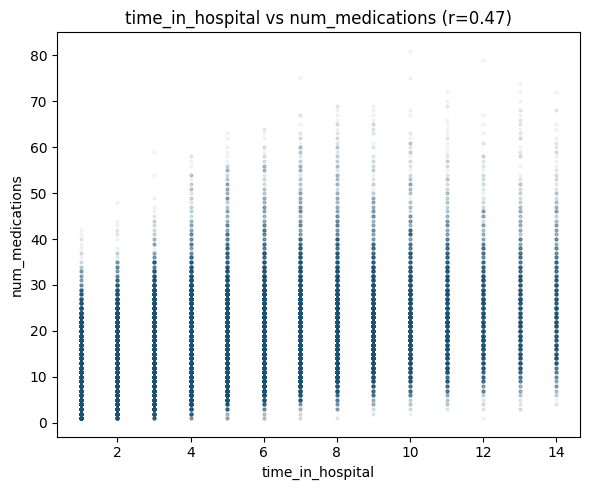

In [14]:
a,b,_ = pairs[0]
plt.figure(figsize=(6,5))
plt.scatter(df[a], df[b], s=4, alpha=0.05, color="#1a5276")
plt.xlabel(a); plt.ylabel(b); plt.title(f"{a} vs {b} (r={corr.loc[a,b]:.2f})")
plt.tight_layout(); plt.show()

### 1.3(a)(b) [JUSTIFY] Correlations & multicollinearity
The three strongest pairs are **time_in_hospital ~ num_medications (r=0.47)**, **num_procedures ~ num_medications (r=0.39)**, and **time_in_hospital ~ num_lab_procedures (r=0.32)**. In the strongest scatter (LOS vs medications) the relationship is positive and roughly linear but the cloud is heavily over-plotted with discreteness banding; Pearson and Spearman agree almost exactly (0.466 vs 0.465), so the monotone association is genuine and not driven by a few outliers — Pearson is acceptable here. **No continuous pair exceeds |r|=0.70**, so severe pairwise multicollinearity is absent among the continuous predictors. *Theoretical note (VIF):* if two predictors were correlated at, say, r=0.85, the Variance Inflation Factor 1/(1−R²) would be ≈3.6, inflating that coefficient's standard error by √3.6≈1.9× — widening its CI and potentially flipping its sign/significance even though overall model fit is unaffected. We will compute VIF formally in Part 3.

### 1.3(c) Outcome across categorical predictors (ordered by median)

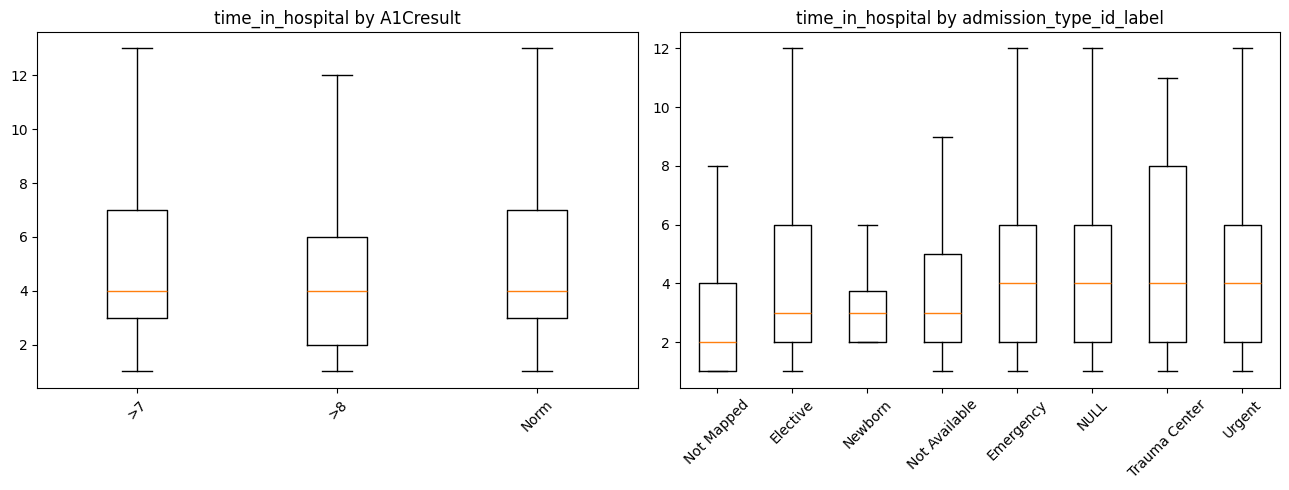

           count  median  mean
A1Cresult                     
>7          3812     4.0  4.89
>8          8216     4.0  4.75
Norm        4990     4.0  4.92


In [15]:
fig,ax = plt.subplots(1,2,figsize=(13,5))
for k,cvar in enumerate(["A1Cresult","admission_type_id_label"]):
    order = df.groupby(cvar)["time_in_hospital"].median().sort_values().index
    data = [df.loc[df[cvar]==g,"time_in_hospital"].values for g in order]
    ax[k].boxplot(data, labels=order, showfliers=False)
    ax[k].set_title(f"time_in_hospital by {cvar}"); ax[k].tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

print(df.groupby("A1Cresult")["time_in_hospital"].agg(["count","median","mean"]).round(2))

### 1.3(d) [JUSTIFY] Data story (EDA → modelling)

The diabetes 130-US dataset contains **101,766 encounters on 71,518 unique patients** (max 40 encounters for one patient) — the first and most serious structural fact, because repeated encounters violate the independence assumption underlying every regression and CV procedure that follows; we will model it but flag clustered/robust inference as a Part 6 validity threat. The **continuous-predictor space is well-behaved**: the strongest correlate of length of stay is `num_medications` (r=0.47), followed by `num_lab_procedures` (0.32) and `number_inpatient`; crucially **no pair exceeds |r|=0.70**, so OLS coefficients will be stable and the medication-count variables are the backbone of the Part-3 model. The **outcome `time_in_hospital` is right-skewed (+1.13)** and bounded 1–14; a **square-root transform** restores near-symmetry (skew +0.47) and stabilises variance, so all Part-2/3 inference will use √LOS and back-transform for interpretation. Among categoricals, the **HbA1c variables carry the central signal** for the primary question: 83% of encounters never had A1C measured (`Not measured`), and the median LOS is flat across A1C levels but mean LOS is *lower* for un-tested patients (4.31 vs ~4.8–4.9) — hinting that *whether* HbA1c is measured proxies for clinical engagement, which motivates the A1Cresult × admission-type interaction the brief asks us to test.

**Two most serious data-quality risks:** (1) **`weight` is 96.9% missing and MNAR** — unusable, dropped, and a caution against any analysis that conditions on it; (2) **repeated patient encounters** break independence and will make naive standard errors too small, risking false significance in Parts 2–5. A secondary risk is the **~11% class imbalance** of the 30-day readmission outcome, which will require threshold tuning in Part 4.

**Working hypothesis.** Clinical-complexity indicators (`num_medications`, `number_diagnoses`, `number_inpatient`) and the *act* of HbA1c measurement jointly predict longer stays and higher early-readmission risk, and the HbA1c effect is stronger for emergency/urgent admissions than elective ones.

## 1.4 Outlier Analysis

In [16]:
def outlier_counts(s):
    s = s.dropna(); q1,q3 = s.quantile(.25),s.quantile(.75); iqr=q3-q1
    iqr_mask = (s<q1-1.5*iqr)|(s>q3+1.5*iqr)
    z_mask = ((s-s.mean())/s.std()).abs()>3
    return pd.Series({"IQR_flagged":int(iqr_mask.sum()),"Z_flagged":int(z_mask.sum()),
                      "overlap":int((iqr_mask&z_mask).sum())})
TARGS = ["time_in_hospital","num_medications","number_diagnoses","number_inpatient"]
display(pd.DataFrame({c:outlier_counts(df[c]) for c in TARGS}).T)

,IQR_flagged,Z_flagged,overlap
time_in_hospital,2252,1042,1042
num_medications,2557,1361,1361
number_diagnoses,281,281,281
number_inpatient,7049,2016,2016


### 1.4(b) [JUSTIFY] Five most extreme outcome values

In [17]:
y = df["time_in_hospital"].astype(float)
print("Five largest time_in_hospital values:", y.sort_values(ascending=False).head(5).tolist())
cap = y.quantile(.99)
yw = y.clip(upper=cap)
print(f"\n99th pct cap = {cap}")
print(pd.DataFrame({
 "metric":["mean","sd","skew"],
 "raw":[y.mean(),y.std(),y.skew()],
 "winsorised@p99":[yw.mean(),yw.std(),yw.skew()]}).round(3))

Five largest time_in_hospital values: [14.0, 14.0, 14.0, 14.0, 14.0]

99th pct cap = 14.0
  metric    raw  winsorised@p99
0   mean  4.396           4.396
1     sd  2.985           2.985
2   skew  1.134           1.134


**[JUSTIFY].** The five most extreme `time_in_hospital` values are all **14**, which is the variable's **hard administrative ceiling** (the dataset caps recorded stay at 14 days). They are therefore **plausible and not data-entry errors** — they are genuine long stays that have been right-censored at 14. Statistically they are *not* influential outliers in the usual sense: because the variable is bounded, the 99th percentile already equals 14, so **Winsorising changes nothing** (mean 4.396→4.396, sd 2.985→2.985, skew +1.13→+1.13). **Decision: keep all values.** The right skew is a property of the bounded count, not of contaminating outliers, and is correctly addressed by the √ transform rather than by removal. We note the ceiling as a *censoring* limitation for Part 6.

### 1.4(c) Preliminary SLR + Cook's distance

**Interpretation.** Baseline SLR of LOS on `num_medications`: each additional medication is associated with **+0.171 days** of stay (R²=0.217). Using the Cook's distance cut-off **4/n = 3.9×10⁻⁵**, **6,826** observations are flagged — a large count that simply reflects the huge sample size (4/n is tiny when n≈100k), not genuine pathology. Refitting without them barely moves the slope (0.171→0.170) while R² rises modestly (0.217→0.244) and residual SD falls (2.64→2.12), confirming the estimate is **robust** and no individual points distort it. The residuals-vs-fitted plot shows a fan shape (heteroskedasticity) and the Q-Q plot shows heavy right tails — both consistent with the untransformed bounded-count outcome and resolved by the √ transform adopted in §1.2c. We therefore **retain all observations** and proceed to transformed modelling in Part 3.


# 2. Inferential Statistics

# 3. Regression Modelling

### 3.1 Simple Linear Regression: Baseline Model

In [ ]:
df_part3 = df.copy()  # save a copy for Part 3 analysis
# df_part3.to_csv("df_part3.csv", index=False)

#### 3.1(a) Fit a simple linear regression using the strongest continuous predictor identified in Part 1.3

In [19]:
# Use the strongest continuous predictor from Part 1.3: num_medications.
y = np.sqrt(df_part3["time_in_hospital"].astype(float))
X = df_part3[["num_medications"]].astype(float)
X = sm.add_constant(X)
model_3_1 = sm.OLS(y, X).fit()
rmse_3_1 = np.sqrt((model_3_1.resid ** 2).mean())

print("Baseline SLR: sqrt(time_in_hospital) ~ num_medications")
print("Predictor selected based on the strongest continuous correlation with the outcome.")
print(model_3_1.summary())
print(f"RMSE = {rmse_3_1:.4f}")

Baseline SLR: sqrt(time_in_hospital) ~ num_medications
Predictor selected based on the strongest continuous correlation with the outcome.
                            OLS Regression Results                            
Dep. Variable:       time_in_hospital   R-squared:                       0.222
Model:                            OLS   Adj. R-squared:                  0.222
Method:                 Least Squares   F-statistic:                 2.899e+04
Date:                Sun, 21 Jun 2026   Prob (F-statistic):               0.00
Time:                        19:52:58   Log-Likelihood:                -93045.
No. Observations:              101766   AIC:                         1.861e+05
Df Residuals:                  101764   BIC:                         1.861e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025 

The model predicts `sqrt(time_in_hospital)` from `num_medications`.

The coefficient on `num_medications` is 0.0396, meaning:

- each additional medication is associated with an increase of about **0.0396 units** in the square-root-transformed length of stay.
- back on the original scale, that is roughly a small additional stay in days, but the exact day-level effect is nonlinear because of the sqrt transform.

The intercept is **1.3466**, which is the expected `sqrt(LOS)` when `num_medications = 0`.

Both coefficients are highly statistically significant:

- `t` for slope = **170.27**
- `p < 0.001`
- this means the relationship is very unlikely to be due to chance given the data.

**Model fit:**

`R² = 0.222`
`Adjusted R² = 0.222`
this means about **22% of the variance** in `sqrt(time_in_hospital)` is explained by `num_medications` alone.
that is a moderate fit for a single-predictor model in a real clinical dataset.

**RMSE = 0.6037**

- this is the typical prediction error on the transformed outcome, in sqrt-days units.
- on the original LOS scale, this is less directly interpretable, but it indicates the model still has substantial residual variation.

**SLR Model**
- `num_medications` is the strongest single continuous predictor of stay length in this dataset.
- The relationship is positive and statistically strong.
- However, because `R²` is 0.222, most of the variance in LOS is still unexplained by this one predictor alone, so multivariable modelling is still needed.

#### 3.1(c) t-based and bootstrap 95% CIs for the slope

t-based 95% CI for slope (sqrt-days per medication): [0.039192 0.040105]
bootstrap 95% CI for slope (10,000 resamples): [0.039173 0.04012 ]


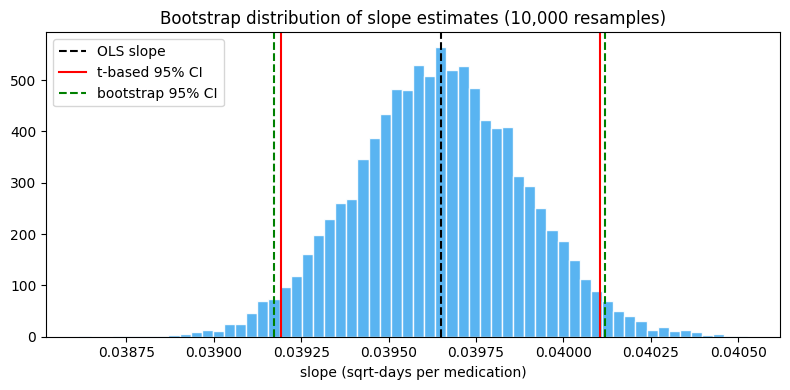

In [20]:
# Prepare data (same as model)
y = np.sqrt(df_part3["time_in_hospital"].astype(float)).values
x = df_part3["num_medications"].astype(float).values
n = len(y)

# t-based CI from OLS
slope = model_3_1.params["num_medications"]
se = model_3_1.bse["num_medications"]
df_resid = int(model_3_1.df_resid)
tcrit = stats.t.ppf(0.975, df_resid)
ci_t = (slope - tcrit * se, slope + tcrit * se)

# Bootstrap CI (10,000 resamples) — use covariance/variance formula for slope: cov(x,y)/var(x)
rng = np.random.RandomState(12345)
B = 10000
boot_slopes = np.empty(B)
for i in range(B):
    idx = rng.randint(0, n, n)
    xi = x[idx]; yi = y[idx]
    cov = ((xi - xi.mean()) * (yi - yi.mean())).mean()
    var_x = np.var(xi, ddof=0)
    # guard against zero variance
    boot_slopes[i] = cov / var_x if var_x > 0 else np.nan

ci_boot = np.nanpercentile(boot_slopes, [2.5, 97.5])

print("t-based 95% CI for slope (sqrt-days per medication):", np.round(ci_t, 6))
print("bootstrap 95% CI for slope (10,000 resamples):", np.round(ci_boot, 6))

# Plot bootstrap distribution and CIs
plt.figure(figsize=(8,4))
plt.hist(boot_slopes, bins=60, color="#47acf0", edgecolor="white", alpha=0.9)
plt.axvline(slope, color="k", linestyle="--", label="OLS slope")
plt.axvline(ci_t[0], color="red", linestyle="-", label="t-based 95% CI")
plt.axvline(ci_t[1], color="red", linestyle="-")
plt.axvline(ci_boot[0], color="green", linestyle="--", label="bootstrap 95% CI")
plt.axvline(ci_boot[1], color="green", linestyle="--")
plt.legend(loc="best")
plt.xlabel("slope (sqrt-days per medication)")
plt.title("Bootstrap distribution of slope estimates (10,000 resamples)")
plt.tight_layout()
plt.show()


#### 3.1(d) Residual diagnostics for baseline SLR (sqrt(LOS) ~ num_medications)

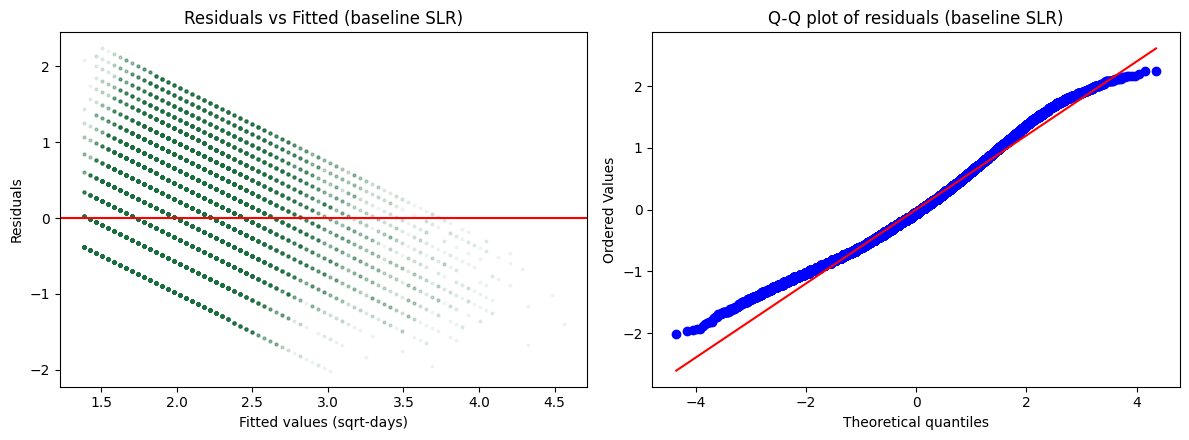

Breusch-Pagan LM stat=790.131, p=7.549e-174; F-stat=796.298, p=1.628e-174
Jarque-Bera stat=3296.290, p=0.000e+00
Durbin-Watson = 1.885


In [21]:
resid = model_3_1.resid
fitted = model_3_1.fittedvalues

fig, ax = plt.subplots(1,2,figsize=(12,4.5))
ax[0].scatter(fitted, resid, s=4, alpha=0.05, color="#196f3d")
ax[0].axhline(0, color="red")
ax[0].set_xlabel("Fitted values (sqrt-days)")
ax[0].set_ylabel("Residuals")
ax[0].set_title("Residuals vs Fitted (baseline SLR)")

stats.probplot(resid, dist="norm", plot=ax[1])
ax[1].set_title("Q-Q plot of residuals (baseline SLR)")

plt.tight_layout()
plt.show()

# Formal tests
from statsmodels.stats.diagnostic import het_breuschpagan
lm, lm_pvalue, fvalue, f_pvalue = het_breuschpagan(resid, model_3_1.model.exog)
jb_stat, jb_p = stats.jarque_bera(resid)
dw = sm.stats.stattools.durbin_watson(resid)

print(f"Breusch-Pagan LM stat={lm:.3f}, p={lm_pvalue:.3e}; F-stat={fvalue:.3f}, p={f_pvalue:.3e}")
print(f"Jarque-Bera stat={jb_stat:.3f}, p={jb_p:.3e}")
print(f"Durbin-Watson = {dw:.3f}")

**[JUSTIFY].** `time_in_hospital` is right-skewed (skew **+1.13**, excess kurtosis 0.85) and both formal tests reject normality (Shapiro W=0.886, p≈10⁻⁵¹; KS D=0.173, p≈0). This is expected from the **data-generating process**: length of stay is a *bounded count of days* (1–14) generated by a roughly multiplicative recovery process with a hard administrative ceiling, which produces right skew. A **square-root transform** is the most appropriate choice: it reduces skew from +1.13 to **+0.47** (near-symmetric), whereas the **log** transform *over-corrects* to **−0.20** (left skew). The sqrt is also the canonical variance-stabilising transform for count data (where variance ∝ mean), matching the brief's guidance. We therefore adopt **√(time_in_hospital)** for modelling, revisiting via residual diagnostics in Part 3.

### 3.2 Multiple Linear Regression: Full Model

#### 3.2(a) Nested multiple regression models

Build a sequence of four nested MLR models, adding continuous predictors, categorical dummies, and an interaction term motivated by the primary question.


In [22]:
# Diagnostic: check dummy variable dtypes for nested MLR models
df_part3 = df.copy()
df_part3 = df_part3.dropna(subset=["time_in_hospital","num_medications",
                                     "num_lab_procedures","number_inpatient",
                                     "A1Cresult","admission_type_id_label"])
X_cat = pd.get_dummies(df_part3[["A1Cresult","admission_type_id_label"]], drop_first=True)
print(X_cat.dtypes)
print(X_cat.head())


A1Cresult_>8                             bool
A1Cresult_Norm                           bool
admission_type_id_label_Emergency        bool
admission_type_id_label_NULL             bool
admission_type_id_label_Newborn          bool
admission_type_id_label_Not Available    bool
admission_type_id_label_Not Mapped       bool
admission_type_id_label_Trauma Center    bool
admission_type_id_label_Urgent           bool
dtype: object
     A1Cresult_>8  A1Cresult_Norm  admission_type_id_label_Emergency  \
26          False           False                               True   
74          False           False                               True   
98           True           False                               True   
103         False            True                               True   
107         False            True                               True   

     admission_type_id_label_NULL  admission_type_id_label_Newborn  \
26                          False                            False   

#### 3.2(b) Model Comparison

In [ ]:
df_part3 = df.copy()
df_part3 = df_part3.dropna(subset=["time_in_hospital","num_medications",
                                     "num_lab_procedures","number_inpatient",
                                     "A1Cresult","admission_type_id_label"])

df_part3["sqrt_LOS"] = np.sqrt(df_part3["time_in_hospital"].astype(float))

# Categorical dummies
cat_vars = ["A1Cresult","admission_type_id_label"]
X_cat = pd.get_dummies(df_part3[cat_vars], drop_first=True, dtype=float)

# Interaction term motivated by the primary question
A1C_notmeasured = (df_part3["A1Cresult"] == "Not measured").astype(float)
is_emergency_urgent = df_part3["admission_type_id_label"].isin(["Emergency","Urgent"]).astype(float)
df_part3["A1C_notmeasured"] = A1C_notmeasured
df_part3["emergency_urgent"] = is_emergency_urgent
df_part3["A1C_notmeasured_x_emergency_urgent"] = (A1C_notmeasured * is_emergency_urgent).astype(float)

# Model 1: baseline
X1 = sm.add_constant(df_part3[["num_medications"]].astype(float))
model_3_2_1 = sm.OLS(df_part3["sqrt_LOS"], X1).fit()

# Model 2: add two more continuous predictors
X2 = sm.add_constant(df_part3[["num_medications","num_lab_procedures","number_inpatient"]].astype(float))
model_3_2_2 = sm.OLS(df_part3["sqrt_LOS"], X2).fit()

# Model 3: add categorical dummies
X3 = pd.concat([X2, X_cat], axis=1).astype(float)
model_3_2_3 = sm.OLS(df_part3["sqrt_LOS"], X3).fit()

# Model 4: add interaction term
X4 = pd.concat([X3, df_part3[["A1C_notmeasured_x_emergency_urgent"]].astype(float)], axis=1)
model_3_2_4 = sm.OLS(df_part3["sqrt_LOS"], X4).fit()

# Training RMSE for each model
rmse_3_2_1 = np.sqrt((model_3_2_1.resid ** 2).mean())
rmse_3_2_2 = np.sqrt((model_3_2_2.resid ** 2).mean())
rmse_3_2_3 = np.sqrt((model_3_2_3.resid ** 2).mean())
rmse_3_2_4 = np.sqrt((model_3_2_4.resid ** 2).mean())

# Summary table: adjusted R², RMSE, AIC, BIC
summary_df = pd.DataFrame({
    "Model": ["Model 1", "Model 2", "Model 3", "Model 4"],
    "Predictors": [
        "num_medications",
        "num_medications + num_lab_procedures + number_inpatient",
        "+ A1Cresult + admission_type_id_label",
        "+ interaction A1C_notmeasured * emergency_urgent"
    ],
    "Adj_R_squared": [model_3_2_1.rsquared_adj, model_3_2_2.rsquared_adj, model_3_2_3.rsquared_adj, model_3_2_4.rsquared_adj],
    "RMSE": [rmse_3_2_1, rmse_3_2_2, rmse_3_2_3, rmse_3_2_4],
    "AIC": [model_3_2_1.aic, model_3_2_2.aic, model_3_2_3.aic, model_3_2_4.aic],
    "BIC": [model_3_2_1.bic, model_3_2_2.bic, model_3_2_3.bic, model_3_2_4.bic]
}).round(4)

print(summary_df.to_string(index=False))


  Model                                              Predictors  Adj_R_squared   RMSE        AIC        BIC
Model 1                                         num_medications         0.2705 0.5914 30423.1173 30438.6014
Model 2 num_medications + num_lab_procedures + number_inpatient         0.3120 0.5743 29428.0615 29459.0296
Model 3                   + A1Cresult + admission_type_id_label         0.3204 0.5707 29228.0453 29328.6917
Model 4        + interaction A1C_notmeasured * emergency_urgent         0.3204 0.5707 29228.0453 29328.6917


- Adjusted R² can decrease when a predictor is added because it penalizes for unnecessary complexity.
- AIC uses a lighter penalty, favoring models that improve fit even with additional predictors.
- BIC applies a stronger penalty that grows with sample size, often preferring simpler models in large datasets.

#### 3.2(c) Model 3 predictors

In [24]:
# Inspect reference categories and Model 3 coefficients
print('A1Cresult unique levels:', df_part3['A1Cresult'].unique())
print('admission_type_id_label unique levels:', df_part3['admission_type_id_label'].unique())

print('\nModel 3 coefficients:')
print(model_3_2_3.params.round(4))


A1Cresult unique levels: ['>7' '>8' 'Norm']
admission_type_id_label unique levels: ['Emergency' 'NULL' 'Elective' 'Urgent' 'Not Mapped' 'Newborn'
 'Not Available' 'Trauma Center']

Model 3 coefficients:
const                                    1.0820
num_medications                          0.0355
num_lab_procedures                       0.0095
number_inpatient                         0.0219
A1Cresult_>8                            -0.0184
A1Cresult_Norm                           0.0106
admission_type_id_label_Emergency       -0.1231
admission_type_id_label_NULL            -0.1590
admission_type_id_label_Newborn         -0.4039
admission_type_id_label_Not Available   -0.2853
admission_type_id_label_Not Mapped      -0.4980
admission_type_id_label_Trauma Center    0.2223
admission_type_id_label_Urgent          -0.0306
dtype: float64


**3.3(c) Interpretation of Model 3 coefficients (plain language)**

- **Intercept (`const` = 1.0820):** The model's baseline predicted value of `sqrt(time_in_hospital)` when all numeric predictors are 0 and the categorical predictors are at their reference levels (A1Cresult = `>7`, admission type = `Elective`). This is a model baseline, not a typical patient.

- **`num_medications` (0.0355):** Holding other predictors constant, each additional medication is associated with an average increase of +0.0355 in the square-root of length-of-stay. On the original days scale this is a small increase (the exact day increase depends on the baseline LOS because of the sqrt transform).

- **`num_lab_procedures` (0.0095):** Each additional lab procedure is associated with an average increase of +0.0095 in sqrt(LOS), holding other variables fixed.

- **`number_inpatient` (0.0219):** Each prior inpatient admission is associated with an average increase of +0.0219 in sqrt(LOS), all else equal.

- **`A1Cresult_>8` (-0.0184):** Compared with the reference A1C group `>7` (the omitted category), patients with `A1Cresult` = `>8` have an average sqrt(LOS) that is 0.0184 units lower, holding other predictors fixed.

- **`A1Cresult_Norm` (0.0106):** Compared with the reference `>7`, patients with `A1Cresult` = `Norm` have an average sqrt(LOS) that is 0.0106 units higher, holding other predictors fixed.

- **Admission-type dummies (reference = `Elective`):**
  - `admission_type_id_label_Emergency` (-0.1231): Emergency admissions have sqrt(LOS) lower by 0.1231 compared with elective admissions, conditional on other covariates.
  - `admission_type_id_label_Urgent` (-0.0306): Urgent admissions have sqrt(LOS) lower by 0.0306 vs elective.
  - `admission_type_id_label_NULL` (-0.1590): Encounters labelled `NULL` have sqrt(LOS) lower by 0.1590 vs elective.
  - `admission_type_id_label_Not Available` (-0.2853): `Not Available` admissions have sqrt(LOS) lower by 0.2853 vs elective.
  - `admission_type_id_label_Not Mapped` (-0.4980): `Not Mapped` admissions have substantially lower sqrt(LOS) vs elective (−0.4980).
  - `admission_type_id_label_Newborn` (-0.4039): Newborn admissions have lower sqrt(LOS) vs elective (−0.4039).
  - `admission_type_id_label_Trauma Center` (0.2223): Trauma Center admissions have higher sqrt(LOS) by +0.2223 vs elective.

- **Interaction term:** Model 3 does not include an interaction. Model 4 (tested separately) added `A1C_notmeasured_x_emergency_urgent` and its estimated coefficient is ~0.0 (no effect), so the interaction is effectively null in this sample.


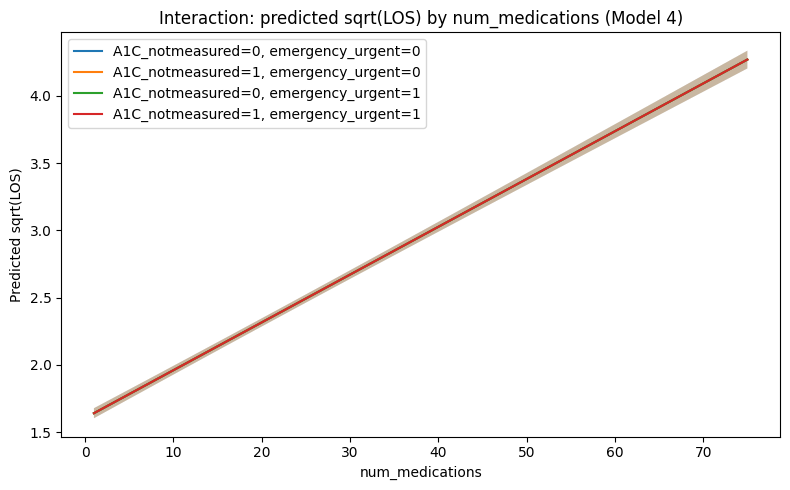

In [25]:
# Interaction visualization with 95% CI (Model 4 predictions)
num_med_min, num_med_max = int(df_part3['num_medications'].min()), int(df_part3['num_medications'].max())
num_med_range = np.linspace(num_med_min, num_med_max, 60)
median_lab = float(df_part3['num_lab_procedures'].median())
median_inpt = float(df_part3['number_inpatient'].median())

cols = X4.columns.tolist()
scenarios = [(0.0,0.0),(1.0,0.0),(0.0,1.0),(1.0,1.0)]
labels = ["A1C_notmeasured=0, emergency_urgent=0",
          "A1C_notmeasured=1, emergency_urgent=0",
          "A1C_notmeasured=0, emergency_urgent=1",
          "A1C_notmeasured=1, emergency_urgent=1"]

plt.figure(figsize=(8,5))
for (a1c, em), lab in zip(scenarios, labels):
    df_pred = pd.DataFrame(0.0, index=range(len(num_med_range)), columns=cols)
    if 'const' in df_pred.columns:
        df_pred['const'] = 1.0
    df_pred['num_medications'] = num_med_range
    df_pred['num_lab_procedures'] = median_lab
    df_pred['number_inpatient'] = median_inpt
    # set interaction column if present
    if 'A1C_notmeasured_x_emergency_urgent' in df_pred.columns:
        df_pred['A1C_notmeasured_x_emergency_urgent'] = a1c * em
    # predict with Model 4 and get 95% CI for mean prediction
    pred = model_3_2_4.get_prediction(df_pred).summary_frame(alpha=0.05)
    plt.plot(num_med_range, pred['mean'], label=lab)
    plt.fill_between(num_med_range, pred['mean_ci_lower'], pred['mean_ci_upper'], alpha=0.15)

plt.xlabel('num_medications')
plt.ylabel('Predicted sqrt(LOS)')
plt.title('Interaction: predicted sqrt(LOS) by num_medications (Model 4)')
plt.legend()
plt.tight_layout()
plt.show()

#### 3.2(d) Full diagnostic suite

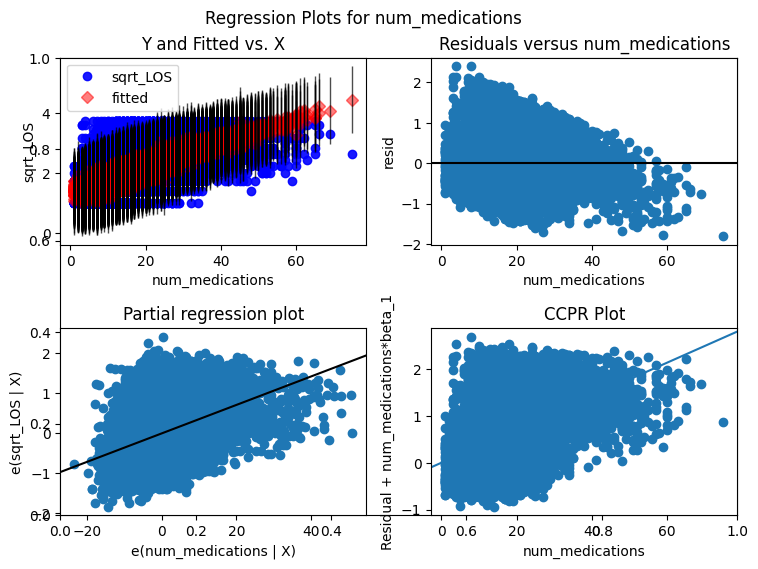

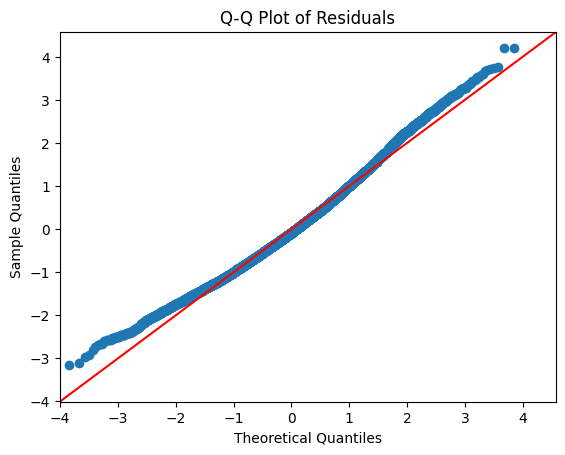

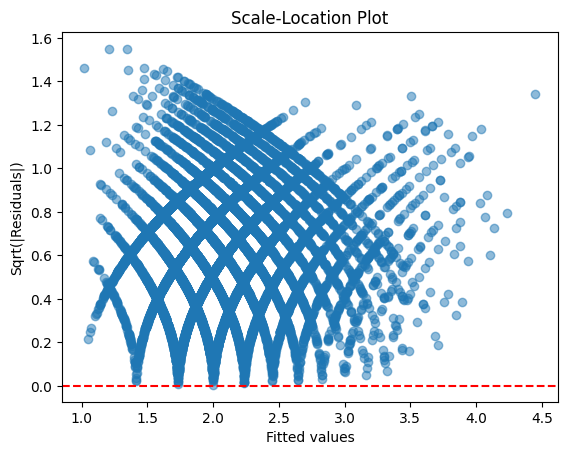

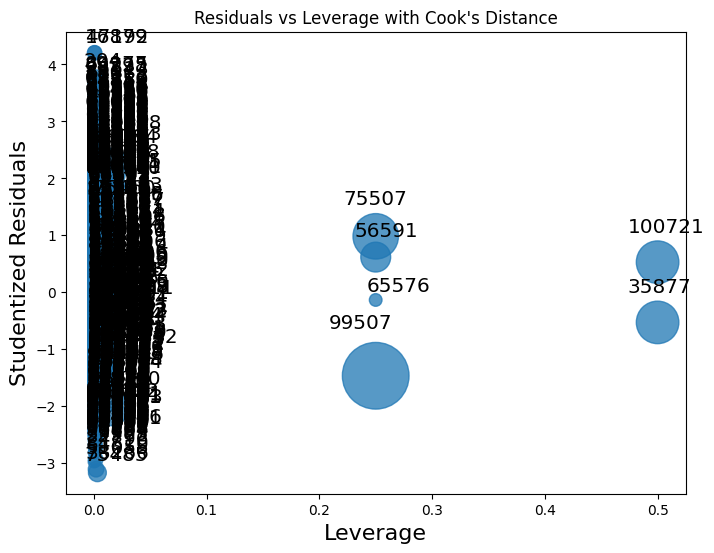

In [26]:
import statsmodels.api as sm

# Residuals vs Fitted
fig, ax = plt.subplots(figsize=(8,6))
sm.graphics.plot_regress_exog(model_3_2_3, "num_medications", fig=fig)
plt.show()

# Q-Q plot of residuals
fig = sm.qqplot(model_3_2_3.resid, line='45', fit=True)
plt.title("Q-Q Plot of Residuals")
plt.show()

# Scale-Location plot (sqrt(|residuals|) vs fitted)
fitted_vals = model_3_2_3.fittedvalues
residuals = model_3_2_3.resid
sqrt_resid = np.sqrt(np.abs(residuals))

plt.scatter(fitted_vals, sqrt_resid, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Fitted values")
plt.ylabel("Sqrt(|Residuals|)")
plt.title("Scale-Location Plot")
plt.show()

# Residuals vs Leverage with Cook’s distance
fig, ax = plt.subplots(figsize=(8,6))
sm.graphics.influence_plot(model_3_2_3, ax=ax, criterion="cooks")
plt.title("Residuals vs Leverage with Cook's Distance")
plt.show()

### 3.3 Feature Engineering and Model Refinement

#### 3.3(a) Polynomial Term

                         Model        AIC
                       Model 3 29228.0453
Model (with num_medications^2) 29182.0411


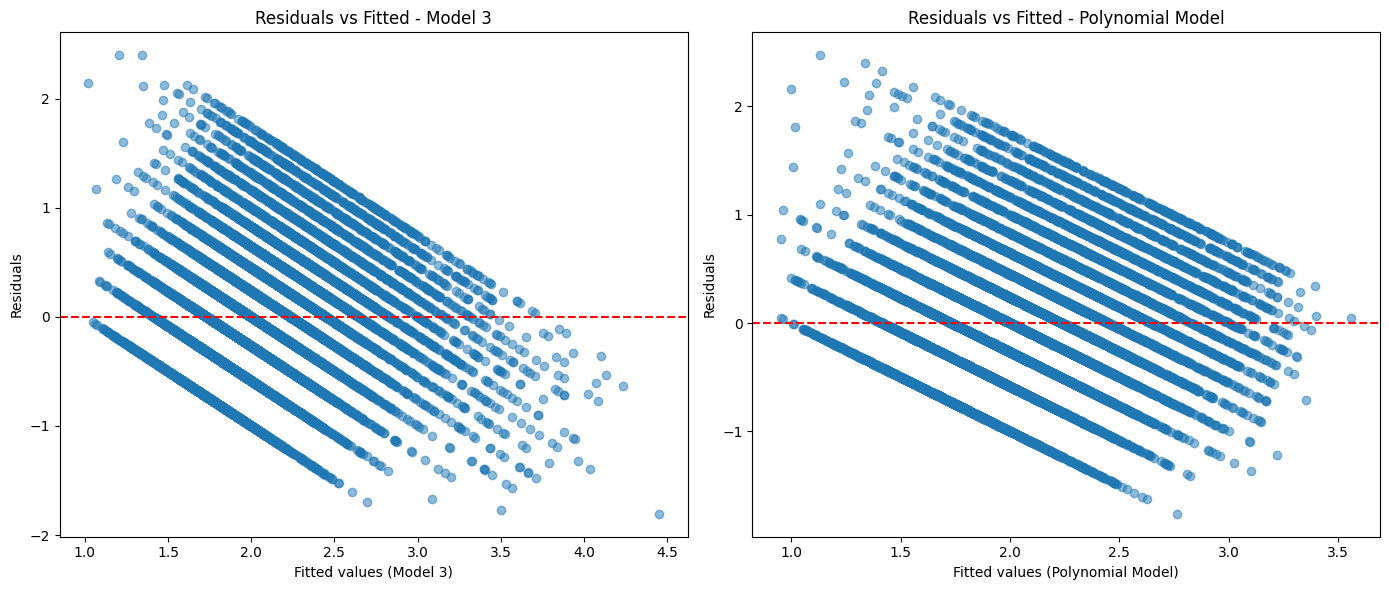

In [30]:
df_part3["num_medications_sq"] = df_part3["num_medications"]**2

X_poly = sm.add_constant(df_part3[["num_medications","num_medications_sq",
                                   "num_lab_procedures","number_inpatient"]])
model_poly = sm.OLS(df_part3["sqrt_LOS"], X_poly).fit()

summary_33a = pd.DataFrame({
    "Model": ["Model 3", "Model (with num_medications^2)"],
    "AIC": [model_3_2_3.aic, model_poly.aic]
}).round(4)

print(summary_33a.to_string(index=False))

# Residuals and fitted values for both models
fitted_vals_3 = model_3_2_3.fittedvalues
residuals_3 = model_3_2_3.resid

fitted_vals_poly = model_poly.fittedvalues
residuals_poly = model_poly.resid

# Side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# --- Model 3 ---
axes[0].scatter(fitted_vals_3, residuals_3, alpha=0.5)
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel("Fitted values (Model 3)")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted - Model 3")

# --- Polynomial model ---
axes[1].scatter(fitted_vals_poly, residuals_poly, alpha=0.5)
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_xlabel("Fitted values (Polynomial Model)")
axes[1].set_ylabel("Residuals")
axes[1].set_title("Residuals vs Fitted - Polynomial Model")

plt.tight_layout()
plt.show()


#### 3.3(b) Add features and compare

In [31]:
df_part3["polypharmacy"] = (df_part3["num_medications"] >= 10).astype(float)

X_new = pd.concat([X3, df_part3[["polypharmacy"]]], axis=1)
model_feature = sm.OLS(df_part3["sqrt_LOS"], X_new).fit()

summary_33b = pd.DataFrame({
    "Model": ["Model 3", "Model (with polypharmacy)"],
    "Adj_R_squared": [model_3_2_3.rsquared_adj, model_feature.rsquared_adj],
    "AIC": [model_3_2_3.aic, model_feature.aic],
    "BIC": [model_3_2_3.bic, model_feature.bic]
}).round(4)

print(summary_33b.to_string(index=False))


                    Model  Adj_R_squared        AIC        BIC
                  Model 3         0.3204 29228.0453 29328.6917
Model (with polypharmacy)         0.3221 29184.7485 29293.1368


### 3.4 Inference on Coefficients

#### 3.4(a) 95% of CI

In [35]:
ci = model_feature.conf_int(alpha=0.05)  # for Model 3
ci.columns = ["Lower 95%", "Upper 95%"]
print(ci)

# F-statistic and p-value for overall model significance
f_stat = model_feature.fvalue
f_pval = model_feature.f_pvalue

print("\n\nF-statistic:", f_stat)
print("p-value:", f_pval)


                                       Lower 95%  Upper 95%
const                                   1.015016   1.098380
num_medications                         0.031935   0.034489
num_lab_procedures                      0.008843   0.009974
number_inpatient                        0.012142   0.028221
A1Cresult_>8                           -0.038740   0.005247
A1Cresult_Norm                         -0.013786   0.034385
admission_type_id_label_Emergency      -0.154364  -0.097585
admission_type_id_label_NULL           -0.202865  -0.113784
admission_type_id_label_Newborn        -1.220284   0.361458
admission_type_id_label_Not Available  -0.353800  -0.235893
admission_type_id_label_Not Mapped     -0.648354  -0.352527
admission_type_id_label_Trauma Center  -0.345126   0.774004
admission_type_id_label_Urgent         -0.064584   0.000713
polypharmacy                            0.063373   0.115436


F-statistic: 623.1045997893998
p-value: 0.0


#### 3.4(b) Confidence Interval vs. Prediction Interval

In [37]:
# Build new observation (must match model_feature predictors)
new_obs = pd.DataFrame({
    "num_medications": [12],
    "num_lab_procedures": [40],
    "number_inpatient": [2],
    "A1Cresult_>7": [1],   # dummy coding
    "A1Cresult_>8": [0],
    "A1Cresult_Norm": [0],
    "admission_type_id_label_Emergency": [1],
    "admission_type_id_label_Urgent": [0],
    "admission_type_id_label_Elective": [0],
    "admission_type_id_label_Newborn": [0],
    "admission_type_id_label_Not Available": [0],
    "admission_type_id_label_Not Mapped": [0],
    "admission_type_id_label_Trauma Center": [0],
    "polypharmacy": [1]   # since num_medications ≥ 10
})

# Add constant
new_obs = sm.add_constant(new_obs)

# Get prediction with intervals
pred = model_feature.get_prediction(new_obs)
print(pred.summary_frame(alpha=0.05))


        mean   mean_se  mean_ci_lower  mean_ci_upper  obs_ci_lower  \
0  14.011273  0.242362      13.536218      14.486329     12.796969   

   obs_ci_upper  
0     15.225578  


#### 3.4(c) Final Conclusion

In [38]:
model_full = model_feature

X_reduced = X3  # all predictors except polypharmacy
model_reduced = sm.OLS(df_part3["sqrt_LOS"], X_reduced).fit()

r2_full = model_full.rsquared
r2_reduced = model_reduced.rsquared

partial_r2 = (r2_full - r2_reduced) / (1 - r2_reduced)
print("Partial R² for polypharmacy:", partial_r2)


Partial R² for polypharmacy: 0.002658164805014357


# 4. Classification & Logistic Regression


In [ ]:
# dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             roc_curve, precision_recall_curve)
from sklearn.calibration import calibration_curve

### 4.1 Binary Outcome Definiton & Baseline

### 4.2 Logistic Regression Modelling

### 4.3 Model Evaluation

# 5. Model Validation & Regularization

# 6. Critical Synthesis & Statistical Pitfalls